In [152]:
import numpy as np
from scipy.signal import fftconvolve
from scipy.special import j1
from scipy.ndimage import shift as ndshift
import matplotlib.pyplot as plt

# ── camera sensor ──────────────────────────────────────────────────────────
H, W       = 256, 256   # camera frame [sensor pixels]
FWC        = 1e4        # full-well capacity [electrons]
RN         = 2.0        # readout noise sigma [ADC]
BIAS       = 0.0        # bias level [ADC]

# ── PSF sub-pixel model ────────────────────────────────────────────────────
R_AIRY_PX  = 1.0        # Airy first-dark-ring radius [camera pixels]
PSF_FINE   = 128        # fine-grid size for PSF [fine pixels, square]
OVERSAMPLE = 32         # fine pixels per camera pixel
#   PSF_FINE / OVERSAMPLE = 4×4 camera-pixel footprint per defect

# ── jitter interface (fine pixels) ────────────────────────────────────────
JITTER_MAX_SPX = OVERSAMPLE   # ±1 camera pixel max; reserved for future use

## model 

In [153]:
# ── 工具函数 ───────────────────────────────────────────────────────────────
def annotated_heatmap(ax, arr, title, fmt='{:.2f}', cmap='coolwarm', fontsize=8,
                      vmin=None, vmax=None):
    """Heatmap with per-cell value annotations.
    vmin/vmax: fixed color range for cross-panel comparison; None = auto.
    """
    im = ax.imshow(arr, cmap=cmap, interpolation='nearest', vmin=vmin, vmax=vmax)
    H, W = arr.shape
    threshold = arr.max() * 0.6 if arr.max() > 0 else 0.5
    for i in range(H):
        for j in range(W):
            ax.text(j, i, fmt.format(arr[i, j]), ha='center', va='center',
                    fontsize=fontsize,
                    color='black' if arr[i, j] > threshold else 'white')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, shrink=0.75)
    return im

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Module 1 — PSF model
# ══════════════════════════════════════════════════════════════════════════

class PSF:
    def __init__(self, r_airy_px=R_AIRY_PX, psf_fine=PSF_FINE, oversample=OVERSAMPLE,
                 jitter_spx=0.0, jitter_spy=0.0, A=1.0):
        self.r_airy_px  = r_airy_px
        self.psf_fine   = psf_fine
        self.oversample = oversample
        self.jitter_spx = jitter_spx
        self.jitter_spy = jitter_spy
        self.A          = A

    @staticmethod
    def _bin2d(img, factor):
        H, W = img.shape
        H2, W2 = H // factor, W // factor
        return (img[:H2*factor, :W2*factor]
                .reshape(H2, factor, W2, factor)
                .sum(axis=(1, 3)))

    def make_fine(self, jitter_spx=None, jitter_spy=None):
        jx = self.jitter_spx if jitter_spx is None else jitter_spx
        jy = self.jitter_spy if jitter_spy is None else jitter_spy
        half = self.psf_fine // 2
        y, x = np.mgrid[-half:half, -half:half].astype(float)
        r = np.sqrt(x**2 + y**2)
        u_safe = np.where(r == 0, 1.0, 3.8317 * r / (self.r_airy_px * self.oversample))
        k = np.where(r == 0, 1.0, (2.0 * j1(u_safe) / u_safe)**2)
        k /= k.sum()
        if jx != 0.0 or jy != 0.0:
            k = ndshift(k, (jy, jx), order=3, mode='constant', cval=0.0)
        return k

    def make_template(self, A=None, jitter_spx=None, jitter_spy=None):
        """Camera-pixel PSF array, sum = A (default: self.A)."""
        a = self.A if A is None else A
        return self._bin2d(self.make_fine(jitter_spx, jitter_spy), self.oversample) * a

    def stamp(self, frame, x_px, y_px, A=None, jitter_spx=None, jitter_spy=None):
        """Add defect PSF centred at (x_px, y_px) into frame (in-place)."""
        tmpl = self.make_template(A, jitter_spx, jitter_spy)
        th, tw = tmpl.shape
        r0, c0 = y_px - th // 2, x_px - tw // 2
        r1, c1 = r0 + th, c0 + tw
        if r0 >= 0 and c0 >= 0 and r1 <= frame.shape[0] and c1 <= frame.shape[1]:
            frame[r0:r1, c0:c1] += tmpl

    def plot(self, A=None, jitter_spx=None, jitter_spy=None, figsize=(13, 4)):
        a      = self.A          if A          is None else A
        jx     = self.jitter_spx if jitter_spx is None else jitter_spx
        jy     = self.jitter_spy if jitter_spy is None else jitter_spy
        k_fine = self.make_fine(jx, jy)
        tmpl   = self.make_template(a, jx, jy)
        n_cam  = self.psf_fine // self.oversample

        fig, axes = plt.subplots(1, 3, figsize=figsize)
        axes[0].imshow(k_fine, cmap='hot', interpolation='nearest')
        axes[0].set_title(f'Airy PSF  {self.psf_fine}×{self.psf_fine} fine px\n'
                          f'r_airy={self.r_airy_px} cam-px = '
                          f'{self.r_airy_px*self.oversample:.0f} fine px')
        axes[1].imshow(k_fine, cmap='hot', interpolation='nearest')
        for i in range(0, self.psf_fine + 1, self.oversample):
            axes[1].axhline(i - 0.5, color='cyan', lw=0.8)
            axes[1].axvline(i - 0.5, color='cyan', lw=0.8)
        axes[1].set_title(f'Bin grid: {self.oversample}×{self.oversample} → 1 cam-px')
        annotated_heatmap(axes[2], tmpl,
                          f'Camera PSF {tmpl.shape[0]}×{tmpl.shape[1]} px\nsum={tmpl.sum():.4f}',
                          fmt='{:.4f}', fontsize=12)
        fig.suptitle(f'PSF  jitter=({jx},{jy}) fine-px  A={a}', fontsize=11)
        plt.tight_layout()
        plt.show()
        return k_fine, tmpl


# ── sanity check ──────────────────────────────────────────────────────────
psf = PSF()
_t  = psf.make_template()
_sz = PSF_FINE // OVERSAMPLE
print(f"Camera PSF  : {_t.shape}  sum={_t.sum():.2f}")
print(f"Inner 2×2   : {_t[_sz//2-1:_sz//2+1, _sz//2-1:_sz//2+1].sum():.2f}  "
      f"({_t[_sz//2-1:_sz//2+1, _sz//2-1:_sz//2+1].sum()/_t.sum()*100:.1f}%)")
print(_t)


In [155]:
# ══════════════════════════════════════════════════════════════════════════
# Module 2 — Background noise model
# ══════════════════════════════════════════════════════════════════════════

class Background:
    def __init__(self, H=H, W=W, rn=RN, bias=BIAS, rng=None):
        self.H    = H
        self.W    = W
        self.rn   = rn
        self.bias = bias
        self.rng  = rng if rng is not None else np.random.RandomState()

    def readout_noise(self):
        """Gaussian readout noise ~ N(bias, rn²)."""
        return self.bias + self.rng.normal(0.0, self.rn, size=(self.H, self.W))

    def sample(self):
        """Combined background frame (all active noise sources)."""
        return self.readout_noise()

    def create_figure(self, figsize=(8, 6), layout='horizontal'):
        if layout == 'horizontal':
            fig, axes = plt.subplots(1, 2, figsize=figsize,
                                     gridspec_kw={'width_ratios': [4, 1]})
        elif layout == 'vertical':
            fig, axes = plt.subplots(2, 1, figsize=figsize,
                                     gridspec_kw={'height_ratios': [4, 1]})
        else:
            raise ValueError("layout must be 'horizontal' or 'vertical'")
        return fig, axes

    def draw(self, axes, frame, title='', defects=None):
        ax_img, ax_hist = axes[0], axes[1]
        vmax = max(np.percentile(frame, 99.9), 3 * self.rn)
        im = ax_img.imshow(frame, cmap='gray', interpolation='nearest',
                           vmin=self.bias - 3 * self.rn, vmax=vmax, aspect='auto')
        if defects:
            for (xd, yd, _) in defects:
                ax_img.plot(xd, yd, 'c+', ms=8, mew=1.2)
        ax_img.set_title(title)
        plt.colorbar(im, ax=ax_img, label='ADC')
        ax_hist.hist(frame.ravel(), bins=100, density=True,
                     color='steelblue', alpha=0.7, orientation='horizontal')
        xg = np.linspace(frame.min(), frame.max(), 300)
        ax_hist.plot(
            np.exp(-0.5 * ((xg - self.bias) / self.rn)**2) / (self.rn * np.sqrt(2 * np.pi)),
            xg, 'r-', lw=1.5, label=f'N({self.bias},{self.rn}²)')
        ax_hist.set_xlabel('density'); ax_hist.legend(fontsize=8); ax_hist.grid(True)

    def plot(self, frame, title='', defects=None, layout='horizontal', figsize=(8, 6)):
        fig, axes = self.create_figure(figsize=figsize, layout=layout)
        self.draw(axes, frame, title, defects)
        plt.tight_layout()
        return fig, axes

### Module 3 — ImageLag forward model
根据lag_model 拟合后的参数带入

In [156]:
# ══════════════════════════════════════════════════════════════════════════
# Module 3 — ImageLag forward model
# ══════════════════════════════════════════════════════════════════════════

class ImageLag:
    """
    Hammerstein image-lag forward model — Q-dependent biexponential kernel.

        r(t, Q) = [Q − f(Q)]·δ(t=0) + f(Q)·h(t; f(Q))

        f(Q)   = Nt·(1−exp(−Q/Qc))                      静态非线性
        h(t;F) = A1(F)·g_fast(t) + (1−A1(F))·g_slow(t)  Q 依赖释放核
        A1(F)  = A1max·(1−exp(−F/Fc1))                   快陷阱占比
        g_slow = (1−α1)·α1^t / Σ,  g_fast = (1−α2)·α2^t / Σ  (窗口归一化)

    标定来源:
        Nt, Qc        : Mitscherlich 拟合  R²=0.996
        α1,α2,A1max,Fc1: 双指数联合全局优化 (lag_model_fit_test.ipynb)
    """

    # ── 默认标定参数 ──────────────────────────────────────────────────
    NT_DEFAULT     = 62.63
    QC_DEFAULT     = 85.4
    ALPHA1_DEFAULT = 0.7779   # 慢陷阱  τ1 ≈ 3.98 帧
    ALPHA2_DEFAULT = 0.2344   # 快陷阱  τ2 ≈ 0.69 帧
    A1MAX_DEFAULT  = 1.0
    FC1_DEFAULT    = 78.5     # 特征填充电荷 [DN]
    LEN_DEFAULT    = 20       # 拖尾窗口（帧）

    def __init__(self,
                 Nt=NT_DEFAULT, Qc=QC_DEFAULT,
                 alpha1=ALPHA1_DEFAULT, alpha2=ALPHA2_DEFAULT,
                 A1max=A1MAX_DEFAULT, Fc1=FC1_DEFAULT,
                 T=LEN_DEFAULT):
        self.Nt     = Nt
        self.Qc     = Qc
        self.alpha1 = alpha1
        self.alpha2 = alpha2
        self.A1max  = A1max
        self.Fc1    = Fc1
        self.T      = T

    # ── 静态非线性 ────────────────────────────────────────────────────
    def f_trap(self, Q):
        """Per-pixel 陷阱填充量"""
        return self.Nt * (1.0 - np.exp(-np.clip(Q, 0, None) / self.Qc))

    def remaining(self, Q):
        return Q - self.f_trap(Q)

    # ── 释放核 ────────────────────────────────────────────────────────
    def kernel(self, f=None):
        """
        Q 依赖双指数释放核，shape (1, T+1)，t=0 为占位 0，其余 Σ=1。
        f : f_trap 标量，None 时取 f→0（纯慢陷阱）。
        """
        f  = max(float(f), 1e-6) if f is not None else 1e-6
        t  = np.arange(1, self.T + 1)
        A1 = self.A1max * (1 - np.exp(-f / self.Fc1))
        g_sl = (1-self.alpha1)*self.alpha1**t;  g_sl /= g_sl.sum()
        g_fa = (1-self.alpha2)*self.alpha2**t;  g_fa /= g_fa.sum()
        h    = A1*g_fa + (1-A1)*g_sl
        return np.concatenate([[0.0], h]).reshape(1, -1)

    # ── 2D forward model ─────────────────────────────────────────────
    def apply(self, frame, return_parts=False):
        """
        frame → out = remaining + lag.
        核用 mean(f_trap) 近似（空间均匀假设）。
        return_parts=True → (out, trapped, remaining, lag)
        """
        H, W    = frame.shape
        trapped = self.f_trap(frame)
        remain  = frame - trapped
        mask    = trapped > 0.01
        f_mean  = float(trapped[mask].mean()) if mask.any() else 1.0
        lag     = fftconvolve(trapped, self.kernel(f_mean), mode='full')[:H, :W]
        out     = remain + lag
        if return_parts:
            return out, trapped, remain, lag
        return out

    # ── 标量冲激响应 ──────────────────────────────────────────────────
    def predict(self, Q, t_max=None):
        """单像素接受 Q DN 时的理论响应，返回 dict。"""
        T   = self.T if t_max is None else t_max
        fQ  = self.f_trap(Q)
        t   = np.arange(1, T + 1)
        A1  = self.A1max * (1 - np.exp(-max(float(fQ), 1e-6) / self.Fc1))
        g_sl = (1-self.alpha1)*self.alpha1**t;  g_sl /= g_sl.sum()
        g_fa = (1-self.alpha2)*self.alpha2**t;  g_fa /= g_fa.sum()
        lag  = fQ * (A1*g_fa + (1-A1)*g_sl)
        return {'peak': Q - fQ, 'lag': lag, 'fQ': fQ, 'A1': A1,
                'sum':  Q - fQ + lag.sum()}

    # ── 参数热更新 ────────────────────────────────────────────────────
    def update(self, **kwargs):
        for k, v in kwargs.items():
            if not hasattr(self, k):
                raise KeyError(f"未知参数: {k}")
            setattr(self, k, v)
        return self

    def __repr__(self):
        tau1 = -1 / np.log(self.alpha1)
        tau2 = -1 / np.log(self.alpha2)
        return (f"ImageLag(Nt={self.Nt}, Qc={self.Qc})\n"
                f"  slow: α1={self.alpha1:.4f}  τ1={tau1:.2f} 帧\n"
                f"  fast: α2={self.alpha2:.4f}  τ2={tau2:.2f} 帧\n"
                f"  A1(F) = {self.A1max} · (1−exp(−F/{self.Fc1}))")

### Module 4 — Detection filter + SNR

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Module 4 — Detection filter + SNR
# ══════════════════════════════════════════════════════════════════════════

class Filter:
    def __init__(self, rn=RN):
        self.rn = rn

    # ── 无滤波器基准：中心 2×2 像素和 ────────────────────────────────
    def box(self, frame, template, cx, cy):
        """
        最简单基准：PSF 中心 2×2 像素之和。
        中心 2×2 对应 template[1:3, 1:3] 区域（4×4 模板）。
        """
        th, tw = template.shape
        r0 = cy - th // 2
        c0 = cx - tw // 2
        return frame[r0+1:r0+3, c0+1:c0+3].sum()

    # ── 匹配滤波器 ────────────────────────────────────────────────────
    def matched(self, frame, template):
        """归一化 MF 响应图。纯白噪声下 std ≈ RN，缺陷峰值 ≈ A·||template||。"""
        h    = template / np.linalg.norm(template)
        resp = fftconvolve(frame, h[::-1, ::-1], mode='same')
        return resp

    # ── Noise Method 1: 理论值 ────────────────────────────────────────
    def sigma_theory(self):
        """2×2 box sum 理论噪声：4 个独立 N(0,RN²) 之和 → std = 2·RN。"""
        return self.rn * 2.0

    # ── Noise Method 2: 经验值（远场采样）────────────────────────────
    def sigma_empirical(self, frame, template, cx, cy,
                        n=2000, excl_r=40, seed=0):
        """
        在远离 (cx,cy) 的背景区随机采样 box sum，取 std。
        包含 lag clutter 等所有实际噪声来源。
        excl_r : 排除半径 [pixels]。
        """
        H, W = frame.shape
        rng  = np.random.RandomState(seed)
        vals = []
        while len(vals) < n:
            ys = rng.randint(2, H - 2, n)
            xs = rng.randint(2, W - 2, n)
            for y, x in zip(ys, xs):
                if abs(y - cy) > excl_r or abs(x - cx) > excl_r:
                    vals.append(self.box(frame, template, x, y))
                if len(vals) >= n:
                    break
        return np.std(vals[:n])

    # ── 经验 SNR（MF）────────────────────────────────────────────────
    def snr(self, frame, template, cx, cy, bg_margin=20):
        """SNR_empirical = MF 峰值 / std(边缘背景的 MF 输出)。返回 (snr, resp, sigma)。"""
        resp   = self.matched(frame, template)
        signal = resp[cy, cx]
        H, W   = frame.shape
        mask   = np.zeros((H, W), bool)
        mask[:bg_margin, :]  = True
        mask[-bg_margin:, :] = True
        mask[:, :bg_margin]  = True
        mask[:, -bg_margin:] = True
        sigma   = resp[mask].std()
        snr_val = signal / sigma if sigma > 0 else np.inf
        return snr_val, resp, sigma

    # ── 理论 SNR 上界（白噪声）───────────────────────────────────────
    def snr_theory(self, template, A):
        """SNR = A · ||template|| / RN"""
        return A * np.linalg.norm(template) / self.rn

    def __repr__(self):
        return (f"Filter(rn={self.rn})\n"
                f"  sigma_theory = {self.sigma_theory():.4f}  (2×2 box)")


# ── 快速验证 ──────────────────────────────────────────────────────────────
_flt  = Filter()
_tmpl = PSF().make_template(A=1.0)
print(_flt)
print(f"||h||      = {np.linalg.norm(_tmpl):.4f}")
for _A in [10, 50, 100]:
    print(f"  SNR_theory(A={_A:3d}) = {_flt.snr_theory(_tmpl, _A):.2f}")


## test 

### show psf output

In [ ]:
psf = PSF(jitter_spx=10, jitter_spy=5, A=1.0)
k_fine, tmpl = psf.plot()


### imagelag convolve psf test




In [ ]:
A   = 100.0
lag = ImageLag()
print(lag)

# ── Step 1: PSF 模板（使用 psf 存储的 jitter）────────────────────
tmpl_A = psf.make_template(A=A)
th, tw = tmpl_A.shape
print(f"\nCamera PSF: {th}×{tw}, sum={tmpl_A.sum():.2f}, max={tmpl_A.max():.2f}")

# ── Step 2: 嵌入 patch（右侧留 T 列给拖尾）───────────────────────
patch_w = tw + lag.T + 1
patch   = np.zeros((th, patch_w))
patch[:, :tw] = tmpl_A

# ── Step 3: lag forward ──────────────────────────────────────────
out, trapped, remaining, lag_only = lag.apply(patch, return_parts=True)
f_mean = float(trapped[trapped > 0.01].mean()) if (trapped > 0.01).any() else 1.0

sum_in, sum_out = patch.sum(), out.sum()
print(f"电荷守恒: Σin={sum_in:.2f}  Σout={sum_out:.2f}  "
      f"差={sum_in-sum_out:+.3f} ({(sum_in-sum_out)/sum_in*100:.3f}%)")

# ── 绘图 ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 9))

ax0 = plt.subplot2grid((3, 6), (0, 0), colspan=2)
annotated_heatmap(ax0, tmpl_A, f'Camera PSF  {th}×{tw}\nsum={tmpl_A.sum():.2f}',
                  fmt='{:.2f}', fontsize=8)

ax1 = plt.subplot2grid((3, 6), (0, 2), colspan=2)
Qs = np.linspace(0, max(300, A*1.2), 200)
ax1.plot(Qs, lag.f_trap(Qs), 'b-', lw=2, label=r'$f(Q)=N_t(1-e^{-Q/Q_c})$')
ax1.axhline(lag.Nt, color='r', ls='--', lw=1, label=f'$N_t={lag.Nt:.1f}$')
ax1.axvline(lag.Qc, color='g', ls='--', lw=1, label=f'$Q_c={lag.Qc:.1f}$')
ax1.scatter(tmpl_A.flatten(), lag.f_trap(tmpl_A.flatten()),
            c='orange', s=20, alpha=0.7, zorder=5, label='PSF pixels')
ax1.set_xlabel('Q [DN]'); ax1.set_ylabel('f(Q) [DN]')
ax1.set_title('静态非线性'); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2 = plt.subplot2grid((3, 6), (0, 4), colspan=2)
t_arr = np.arange(1, lag.T + 1)
for f_val, ls in [(5, ':'), (20, '--'), (f_mean, '-'), (60, '-.')]:
    h_val = lag.kernel(f_val).flatten()[1:]
    A1_val = lag.A1max * (1 - np.exp(-f_val / lag.Fc1))
    ax2.plot(t_arr, h_val, ls, lw=1.5, label=f'f={f_val:.0f}  A1={A1_val:.2f}')
ax2.set_xlabel('τ (frames)'); ax2.set_ylabel('h(τ)')
ax2.set_title('双指数核 h(t; F)')
ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

ax3 = plt.subplot2grid((3, 6), (1, 0), colspan=3)
annotated_heatmap(ax3, trapped,
                  f'trapped = f(Q)\nsum={trapped.sum():.2f}', fmt='{:.2f}', fontsize=7)

ax4 = plt.subplot2grid((3, 6), (1, 3), colspan=3)
annotated_heatmap(ax4, remaining,
                  f'remaining = Q − f(Q)\nsum={remaining.sum():.2f}', fmt='{:.2f}', fontsize=7)

ax5 = plt.subplot2grid((3, 6), (2, 0), colspan=3)
annotated_heatmap(ax5, lag_only,
                  f'lag tail\nsum={lag_only.sum():.2f}  max={lag_only.max():.2f}',
                  fmt='{:.2f}', fontsize=7)

ax6 = plt.subplot2grid((3, 6), (2, 3), colspan=3)
annotated_heatmap(ax6, out,
                  f'out = remaining + lag\nsum={out.sum():.2f}',
                  fmt='{:.2f}', fontsize=7)

n_cam = psf.psf_fine // psf.oversample
fig.suptitle(
    f'PSF + ImageLag forward chain  (A={A})\n'
    f'PSF: {psf.psf_fine}×{psf.psf_fine} fine → {n_cam}×{n_cam} camera px  '
    f'jitter=({psf.jitter_spx},{psf.jitter_spy})    │    '
    f'Lag: Nt={lag.Nt}  Qc={lag.Qc}  α1={lag.alpha1}  α2={lag.alpha2}',
    fontsize=10, y=0.995)

plt.tight_layout()
plt.savefig('psf_lag_integrated.png', dpi=120, bbox_inches='tight')
plt.show()


### background test

In [ ]:
A_SHOW = [80, 100, 150]
cx, cy = W // 2, H // 2
half   = 8

bg    = Background(rn=1, bias=5, rng=np.random.RandomState(42))
noise = bg.sample()
bg.plot(noise, title='Background noise (rn=1, bias=5)', figsize=(7, 5))
plt.show()
psf.plot(figsize=(17, 4))
for A in A_SHOW:
    signal = np.zeros((H, W))
    psf.stamp(signal, cx, cy, A=A)
    out_signal, trapped, remaining, lag_only = lag.apply(signal, return_parts=True)
    frame = signal + noise
    out   = out_signal + noise

    sl = (slice(cy-half, cy+half), slice(cx-half, cx+half))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    annotated_heatmap(axes[0], frame[sl],
                      f'Before lag  A={A}  ({half*2}×{half*2} crop)', fmt='{:.1f}', fontsize=7)
    annotated_heatmap(axes[1], out[sl],
                      f'After lag  (remaining + lag tail + noise)', fmt='{:.1f}', fontsize=7)
    fig.suptitle(f'A={A} ADC', fontsize=11)
    plt.tight_layout()
    plt.show()


#### filter test

In [ ]:
# ── Filter test: box (no-lag / with-lag) + Lag-kernel MF ──────────────────
A_TEST = 100.0
CX, CY = W // 2, H // 2
half   = 4

psf_ft  = PSF(jitter_spx=10, jitter_spy=5, A=A_TEST)
tmpl_ft = psf_ft.make_template(A=1.0)   # normalized shape template
flt_    = Filter(rn=RN)
lag_    = ImageLag()
bg_ft   = Background(rn=RN, bias=BIAS, rng=np.random.RandomState(42))

noise_ = bg_ft.sample()
sig_   = np.zeros((H, W))
psf_ft.stamp(sig_, CX, CY)

frame_nl = sig_              + noise_   # no lag
frame_wl = lag_.apply(sig_) + noise_   # with lag

# ── Build lag-kernel MF template ──────────────────────────────────────────
# Expected noiseless PSF+lag response in a clean frame
lag_resp = lag_.apply(sig_)   # remaining + lag tail, no noise

# Crop symmetric in y, right-extended in x so PSF center lands at tmpl center.
# Template: height=6 (3 above/below CY), width=2*(T+2) so Nh//2 = T+2 aligns
# lag_resp[CY, CX] → tmpl[3, T+2].
MH = 6
NH = 2 * (lag_.T + 2)       # e.g. 48 when T=20  →  Nh//2 = T+2 = 22
r0 = CY - MH // 2           # top row
c0 = CX - (lag_.T + 2)      # left col = CX - 22
tmpl_lag_raw = lag_resp[r0 : r0 + MH, c0 : c0 + NH]
tmpl_lag_n   = tmpl_lag_raw / np.linalg.norm(tmpl_lag_raw)   # unit-energy

# ── Heatmap: crop around defect ──────────────────────────────────────────
sl = (slice(CY - half, CY + half), slice(CX - half, CX + half + lag_.T // 2))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
annotated_heatmap(axes[0], frame_nl[sl], f'No lag  A={A_TEST}', fmt='{:.1f}', fontsize=7)
annotated_heatmap(axes[1], frame_wl[sl], 'With lag + noise',    fmt='{:.1f}', fontsize=7)
annotated_heatmap(axes[2], tmpl_lag_raw,
                  f'Lag-MF template ({MH}x{NH})\n'
                  f'||h||={np.linalg.norm(tmpl_lag_raw):.2f}  sum={tmpl_lag_raw.sum():.2f}',
                  fmt='{:.2f}', fontsize=5)
plt.tight_layout()
plt.show()

# ── Signal measurements ───────────────────────────────────────────────────
s_nl = flt_.box(frame_nl, tmpl_ft, CX, CY)
s_wl = flt_.box(frame_wl, tmpl_ft, CX, CY)

resp_mf = flt_.matched(frame_wl, tmpl_lag_n)
s_mf    = resp_mf[CY, CX]

# ── Noise measurements ────────────────────────────────────────────────────
sigma_th     = flt_.sigma_theory()                                        # 2*RN (box)
sigma_mf_th  = RN                                                         # unit-norm MF in white noise
sigma_nl_emp = flt_.sigma_empirical(frame_nl, tmpl_ft, CX, CY, n=2000, excl_r=40)
sigma_wl_emp = flt_.sigma_empirical(frame_wl, tmpl_ft, CX, CY, n=2000, excl_r=40)

# Empirical MF noise: sample resp_mf at background positions
rng_mf = np.random.RandomState(1)
mf_bg  = []
while len(mf_bg) < 2000:
    ys = rng_mf.randint(2, H - 2, 2000)
    xs = rng_mf.randint(2, W - 2, 2000)
    for y, x in zip(ys, xs):
        if abs(y - CY) > 40 or abs(x - CX) > 40:
            mf_bg.append(resp_mf[y, x])
        if len(mf_bg) >= 2000:
            break
sigma_mf_emp = np.std(mf_bg[:2000])

# ── SNR table ─────────────────────────────────────────────────────────────
hdr = f"{'Filter':22s}  {'signal':>8}  {'sigma_th':>9}  {'sigma_emp':>10}  {'SNR_th':>8}  {'SNR_emp':>8}"
print(hdr)
print('-' * len(hdr))

def row(name, s, s_th, s_emp):
    return (f"{name:22s}  {s:8.2f}  {s_th:9.4f}  {s_emp:10.4f}"
            f"  {s/s_th:8.2f}  {s/s_emp:8.2f}")

print(row('Box (no lag)',   s_nl, sigma_th,    sigma_nl_emp))
print(row('Box (with lag)', s_wl, sigma_th,    sigma_wl_emp))
print(row('Lag-kernel MF',  s_mf, sigma_mf_th, sigma_mf_emp))

snr_nl  = s_nl / sigma_nl_emp
snr_wl  = s_wl / sigma_wl_emp
snr_mf  = s_mf / sigma_mf_emp
print(f"\n  Lag degrades box SNR:       {snr_wl/snr_nl:.3f}x")
print(f"  Lag MF vs box (with lag):   {snr_mf/snr_wl:.3f}x")
print(f"  Lag MF vs box (no lag):     {snr_mf/snr_nl:.3f}x")


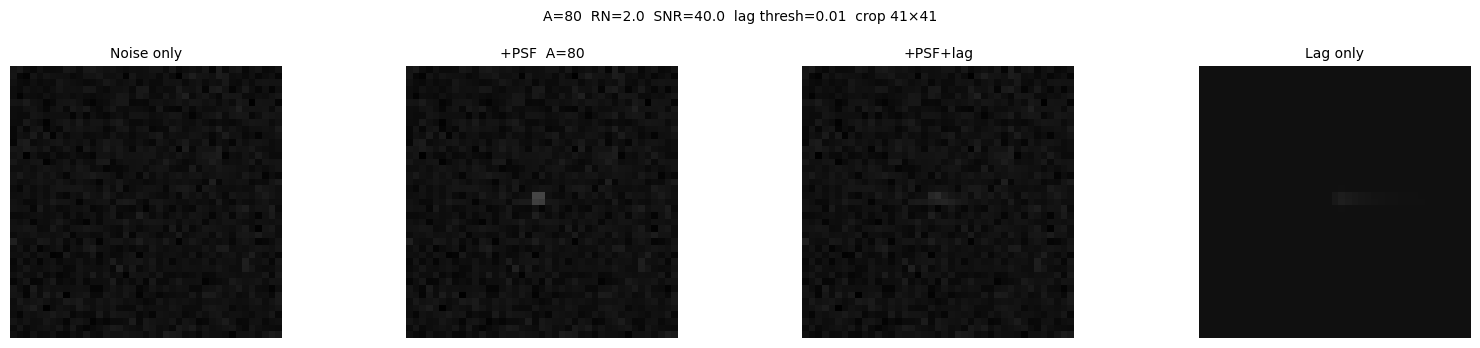

A= 80  PSF peak=19.5  lag peak=5.34  mask px=16


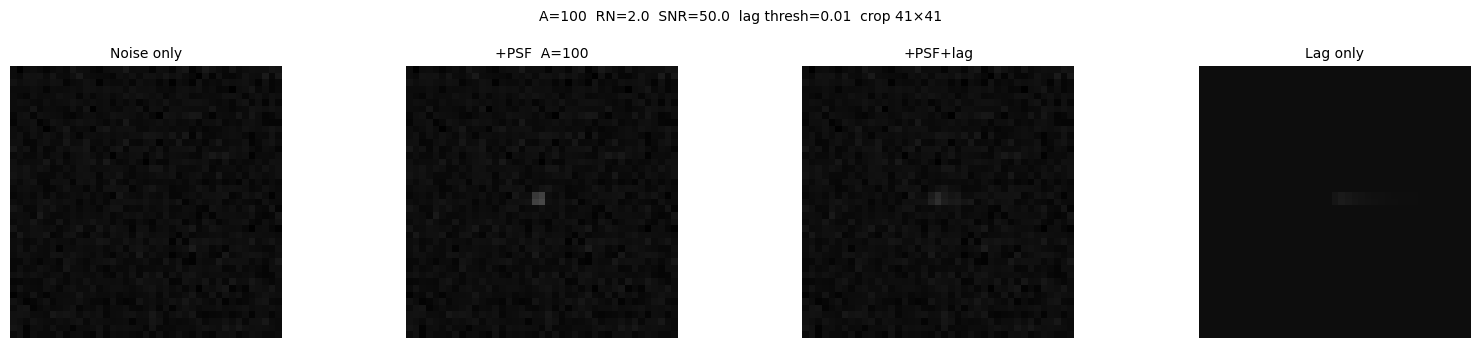

A=100  PSF peak=26.8  lag peak=6.58  mask px=16


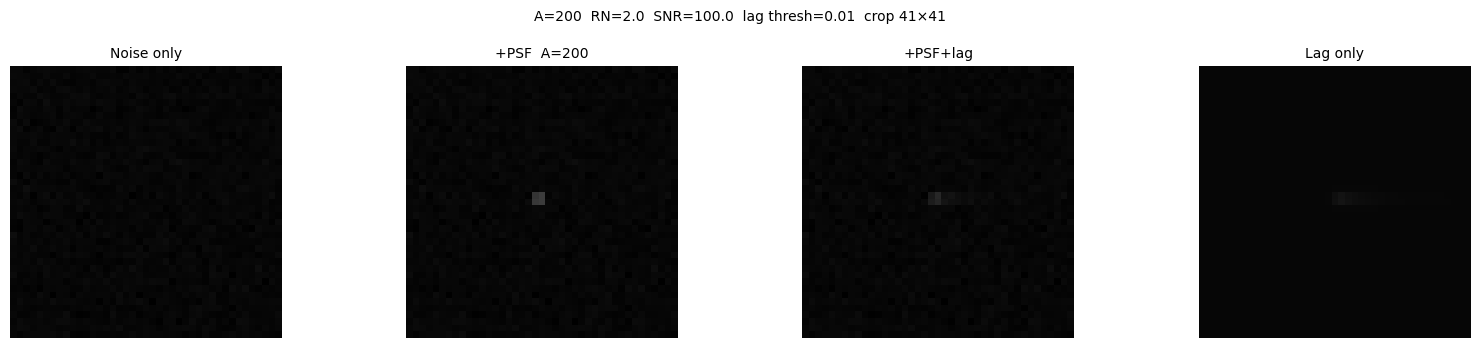

A=200  PSF peak=47.7  lag peak=12.13  mask px=16


In [145]:
# ══════════════════════════════════════════════════════════════════════════
# Demo — PSF + imagelag at A = 20 / 25 / 30 ADC
# Columns: noise only | +PSF | +PSF+lag | lag only
# ══════════════════════════════════════════════════════════════════════════
A_VALS     = [80, 100, 200]
X0, Y0     = W // 2, H // 2
CROP       = 20
LAG_THRESH = 0.01

def show_pipeline(A, bg, psf):
    noise = bg.sample()

    # lag 只作用于纯 PSF 信号，不含噪声
    signal = np.zeros((H, W))
    psf.stamp(signal, X0, Y0, A=A)
    out_signal, trapped, remaining, lag_only = lag.apply(signal, return_parts=True)

    psf_frame = signal + noise       # noise + PSF（lag 前）
    obs       = out_signal + noise   # noise + remaining + lag tail（lag 后）

    sl = (slice(Y0-CROP, Y0+CROP+1), slice(X0-CROP, X0+CROP+1))
    vmin, vmax = -3*RN, A * 1.1

    fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
    for ax, img, title in zip(axes,
                               [noise, psf_frame, obs, lag_only],
                               ['Noise only', f'+PSF  A={A}', '+PSF+lag', 'Lag only']):
        ax.imshow(img[sl], cmap='gray', interpolation='nearest', vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=10); ax.axis('off')

    fig.suptitle(f'A={A}  RN={RN}  SNR={A/RN:.1f}  lag thresh={LAG_THRESH:.2f}  '
                 f'crop {2*CROP+1}×{2*CROP+1}', fontsize=10)
    plt.tight_layout(); plt.show()

    peak     = psf_frame[Y0-2:Y0+2, X0-2:X0+2].max()
    lag_peak = lag_only[Y0-2:Y0+2, X0+1:X0+6].max()
    print(f'A={A:3d}  PSF peak={peak:.1f}  lag peak={lag_peak:.2f}  '
          f'mask px={(signal > LAG_THRESH).sum()}')

bg_demo  = Background(rng=np.random.RandomState(7))
psf_demo = PSF()
for A in A_VALS:
    show_pipeline(A, bg_demo, psf_demo)

### imagelag kernel simulation 